# Error Analysis

Count the number of failures per (generator_name, n_vars, n_samples, algo) quadruplet across all scaling results.

In [1]:
import pandas as pd
from pathlib import Path

# Load all results CSVs
results_dir = Path("results")
dfs = []
for csv_path in sorted(results_dir.glob("*/results.csv")):
    dfs.append(pd.read_csv(csv_path))
df = pd.concat(dfs, ignore_index=True)

print(f"{len(df)} rows loaded from {len(dfs)} experiments")
print(f"Generators: {df['generator_name'].unique()}")
print(f"Algos: {df['algo'].unique()}")
print(f"n_samples: {sorted(df['n_samples'].unique())}")

12000 rows loaded from 10 experiments
Generators: ['sem_laplace' 'sem_gaussian' 'cbn_unif_gauss' 'cbn_exp_clayton'
 'cbn_unif_mixture']
Algos: ['CPC' 'CMIIC' 'MIIC' 'GHC+BDeu' 'NOTEARS' 'NOTEARS Disc.' 'LiNGAM'
 'DAGMA']
n_samples: [np.int64(200), np.int64(500), np.int64(1000), np.int64(3000), np.int64(5000)]


In [2]:
# Count failures per (generator_name, n_vars, n_samples, algo)
df["is_error"] = df["error_msg"].notna()

summary = (
    df.groupby(["generator_name", "n_vars", "n_samples", "algo"])
    .agg(total=("is_error", "count"), n_errors=("is_error", "sum"))
    .reset_index()
)
summary["n_errors"] = summary["n_errors"].astype(int)
summary["error_rate"] = summary["n_errors"] / summary["total"]

# Show only quadruplets with at least one error
errors_only = summary[summary["n_errors"] > 0].sort_values(
    ["generator_name", "algo", "n_vars", "n_samples"]
)
print(f"{len(errors_only)} quadruplets with at least one error (out of {len(summary)} total)")
errors_only

61 quadruplets with at least one error (out of 400 total)


,generator_name,n_vars,n_samples,algo,total,n_errors,error_rate
2,cbn_exp_clayton,10,200,DAGMA,30,10,0.333333
10,cbn_exp_clayton,10,500,DAGMA,30,6,0.200000
18,cbn_exp_clayton,10,1000,DAGMA,30,3,0.100000
26,cbn_exp_clayton,10,3000,DAGMA,30,3,0.100000
34,cbn_exp_clayton,10,5000,DAGMA,30,1,0.033333
...,...,...,...,...,...,...,...
367,sem_laplace,20,200,NOTEARS Disc.,30,9,0.300000
375,sem_laplace,20,500,NOTEARS Disc.,30,4,0.133333
383,sem_laplace,20,1000,NOTEARS Disc.,30,8,0.266667
391,sem_laplace,20,3000,NOTEARS Disc.,30,7,0.233333


In [3]:
# Pivot: error count per algo x (generator, n_vars, n_samples)
pivot = summary.pivot_table(
    index="algo",
    columns=["generator_name", "n_vars", "n_samples"],
    values="n_errors",
    fill_value=0,
)
# Keep only algos that have at least one error
pivot = pivot.loc[pivot.sum(axis=1) > 0]
pivot

generator_name cbn_exp_clayton                                             \
n_vars                      10                       20                     
n_samples                 200  500  1000 3000 5000 200   500   1000  3000   
algo                                                                        
DAGMA                     10.0  6.0  3.0  3.0  1.0  9.0   5.0   4.0   2.0   
LiNGAM                     0.0  1.0  1.0  0.0  0.0  0.0   0.0   0.0   0.0   
NOTEARS                    0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0   
NOTEARS Disc.              3.0  1.0  2.0  2.0  3.0  6.0  12.0  12.0  10.0   

generator_name       ... sem_laplace                                          \
n_vars               ...          10                       20                  
n_samples      5000  ...        200  500  1000 3000 5000 200  500  1000 3000   
algo                 ...                                                       
DAGMA           2.0  ...         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
LiNGAM          0.0  ...         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
NOTEARS         0.0  ...         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
NOTEARS Disc.   9.0  ...         0.0  1.0  0.0  0.0  0.0  9.0  4.0  8.0  7.0   

generator_name       
n_vars               
n_samples      5000  
algo                 
DAGMA           0.0  
LiNGAM          0.0  
NOTEARS         0.0  
NOTEARS Disc.   7.0  

[4 rows x 50 columns]

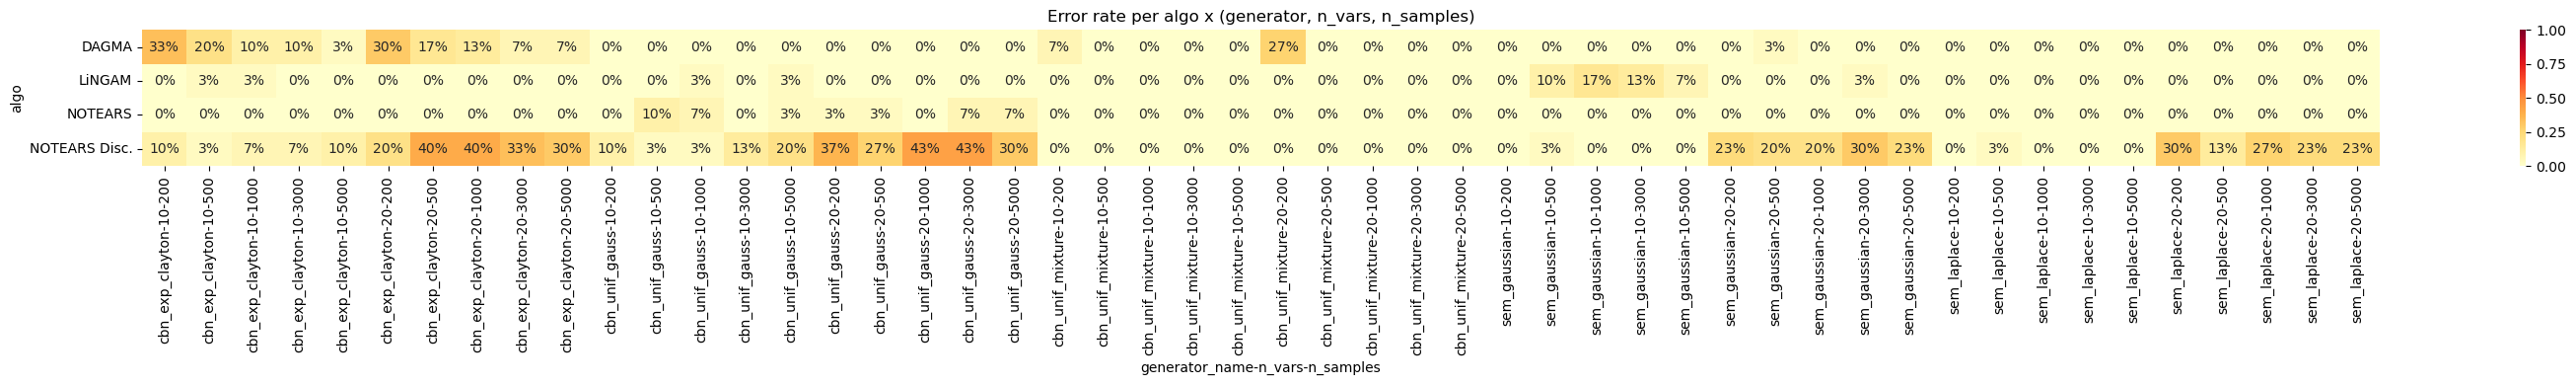

In [4]:
# Heatmap of error rates
import matplotlib.pyplot as plt
import seaborn as sns

rate_pivot = summary.pivot_table(
    index="algo",
    columns=["generator_name", "n_vars", "n_samples"],
    values="error_rate",
    fill_value=0,
)
rate_pivot = rate_pivot.loc[rate_pivot.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(max(14, rate_pivot.shape[1] * 0.6), max(4, rate_pivot.shape[0] * 0.5)))
sns.heatmap(rate_pivot, annot=True, fmt=".0%", cmap="YlOrRd", ax=ax, vmin=0, vmax=1)
ax.set_title("Error rate per algo x (generator, n_vars, n_samples)")
plt.tight_layout()
plt.show()

In [5]:
# Most common error messages
error_rows = df[df["is_error"]].copy()
error_rows["error_short"] = error_rows["error_msg"].str[:80]

print("Most frequent error messages:")
error_rows["error_short"].value_counts().head(10)

Most frequent error messages:


error_short
[pyAgrum] Directed cycle detected: Add a directed cycle in a dag !                  227
[pyAgrum] Partially directed cycle detected: Add a partial directed cycle in a P     61
Name: count, dtype: int64